# FDb winner metric summary

Compare RayTune short-winner FDb runs:
- **Dice** — train job `17934425`
- **Skeleton** — train job `17934427`

Sources: SLURM train `.out` logs (via `biapy_train_track`) and matching `test_results_metrics.csv` under `metrics/biapy/`.

In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd()
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from biapy_work_folder.biapy_train_track import (
    consolidate_training_log,
    plot_training_across_partitions,
)

/scratch/wmz2007/neuroinfo_fruitfly


## Runs

Edit `RUNS` to swap logs / result dirs. Test CSVs are the winner-job outputs paired with each train `.out`.

In [2]:
RUNS = {
    # Dice
    "Dice": {
        "train_out": Path(
            "sbatch/biapy/biapy-aug-zarr-seunet-FDb-dice-rbiapy_fdb_dice_l40s_wc_nopat_short_winner-train-17934425.out"
        ),
        "test_csv": Path(
            "metrics/biapy/biapy-aug-zarr-seunet-FDb-dice/results/"
            "biapy-aug-zarr-seunet-FDb-dice_biapy_fdb_dice_l40s_wc_nopat_short_winner/"
            "test_results_metrics.csv"
        ),
    },
    # Skeleton
    "Skeleton": {
        "train_out": Path(
            "sbatch/biapy/biapy-aug-zarr-seunet-FDb-skel-rbiapy_fdb_skel_l40s_wc_nopat_short_winner-train-17934427.out"
        ),
        "test_csv": Path(
            "metrics/biapy/biapy-aug-zarr-seunet-FDb-skel/results/"
            "biapy-aug-zarr-seunet-FDb-skel_biapy_fdb_skel_l40s_wc_nopat_short_winner/"
            "test_results_metrics.csv"
        ),
    },
}

for name, cfg in RUNS.items():
    print(f"{name}:")
    print(f"  train_out exists={cfg['train_out'].is_file()}  {cfg['train_out']}")
    print(f"  test_csv  exists={cfg['test_csv'].is_file()}  {cfg['test_csv']}")

Dice:
  train_out exists=True  sbatch/biapy/biapy-aug-zarr-seunet-FDb-dice-rbiapy_fdb_dice_l40s_wc_nopat_short_winner-train-17934425.out
  test_csv  exists=True  metrics/biapy/biapy-aug-zarr-seunet-FDb-dice/results/biapy-aug-zarr-seunet-FDb-dice_biapy_fdb_dice_l40s_wc_nopat_short_winner/test_results_metrics.csv
Skeleton:
  train_out exists=True  sbatch/biapy/biapy-aug-zarr-seunet-FDb-skel-rbiapy_fdb_skel_l40s_wc_nopat_short_winner-train-17934427.out
  test_csv  exists=True  metrics/biapy/biapy-aug-zarr-seunet-FDb-skel/results/biapy-aug-zarr-seunet-FDb-skel_biapy_fdb_skel_l40s_wc_nopat_short_winner/test_results_metrics.csv


## Training curves (from `.out`)

In [3]:
train_dfs = {}
for name, cfg in RUNS.items():
    df = consolidate_training_log(cfg["train_out"])
    train_dfs[name] = df
    print(
        f"{name}: {len(df)} epoch(s), "
        f"{df['partition'].nunique() if not df.empty else 0} partition(s), "
        f"cols={list(df.columns)}"
    )

Dice: 200 epoch(s), 1 partition(s), cols=['partition', 'epoch', 'global_step', 'train_loss', 'val_loss', 'train_iou_f', 'train_l1_db', 'val_iou_f', 'val_l1_db', 'lr', 'early_stopped']
Skeleton: 240 epoch(s), 1 partition(s), cols=['partition', 'epoch', 'global_step', 'train_loss', 'val_loss', 'train_iou_f', 'train_l1_db', 'val_iou_f', 'val_l1_db', 'lr', 'early_stopped']


In [4]:
def train_summary_row(name: str, df: pd.DataFrame) -> dict:
    """Best-val-loss epoch + last epoch snapshot."""
    if df.empty:
        return {"run": name, "n_epochs": 0}

    best_i = df["val_loss"].idxmin()
    best = df.loc[best_i]
    last = df.iloc[-1]

    row = {
        "run": name,
        "n_epochs": len(df),
        "early_stopped": bool(df["early_stopped"].any()),
        "best_epoch": int(best["epoch"]),
        "best_global_step": int(best["global_step"]),
        "best_val_loss": float(best["val_loss"]),
        "last_val_loss": float(last["val_loss"]),
        "last_train_loss": float(last["train_loss"]),
    }
    for col in (
        "val_iou_f",
        "val_l1_db",
        "val_skel_recall",
        "train_iou_f",
        "train_skel_recall",
    ):
        if col in df.columns:
            row[f"best_{col}"] = float(best[col])
            row[f"last_{col}"] = float(last[col])
    return row


train_summary = pd.DataFrame(
    [train_summary_row(name, df) for name, df in train_dfs.items()]
).set_index("run")
train_summary.round(4)

,n_epochs,early_stopped,best_epoch,best_global_step,best_val_loss,last_val_loss,last_train_loss,best_val_iou_f,last_val_iou_f,best_val_l1_db,last_val_l1_db,best_train_iou_f,last_train_iou_f
run,,,,,,,,,,,,,
Dice,200,False,135,134,0.1856,0.1964,0.0882,0.4824,0.4586,0.0009,0.0007,0.6707,0.7118
Skeleton,240,False,124,123,-0.1439,-0.0998,-0.1982,0.2486,0.3272,0.0018,0.0014,0.2659,0.3146


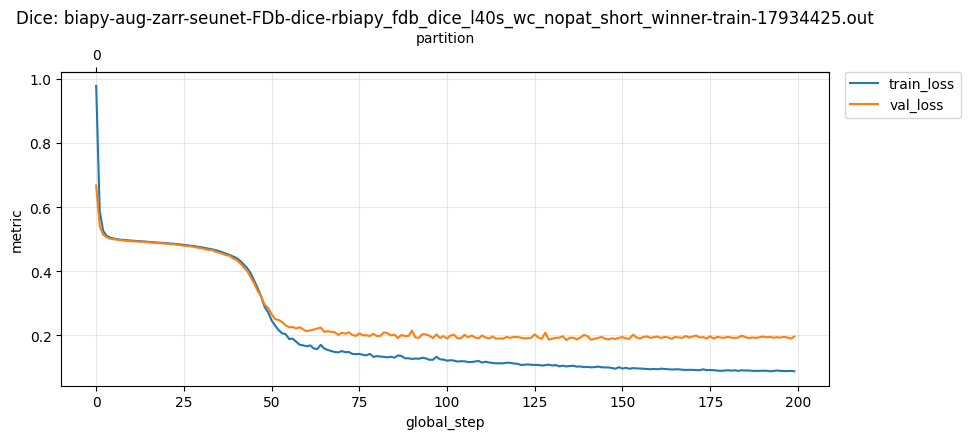

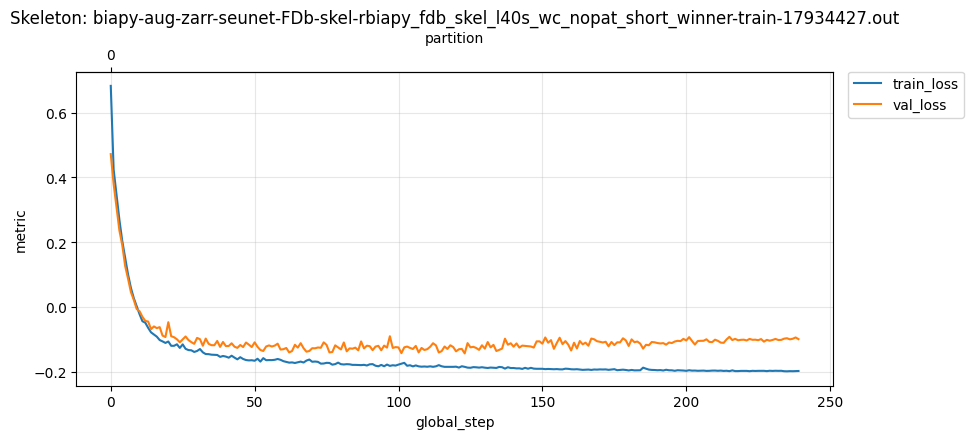

In [5]:
# Per-run loss curves (same helper as training_log_tracker)
for name, df in train_dfs.items():
    if df.empty:
        print(f"skip empty: {name}")
        continue
    fig = plot_training_across_partitions(
        df,
        metrics=("train_loss", "val_loss"),
        title=f"{name}: {RUNS[name]['train_out'].name}",
    )
    plt.show()
    plt.close(fig)

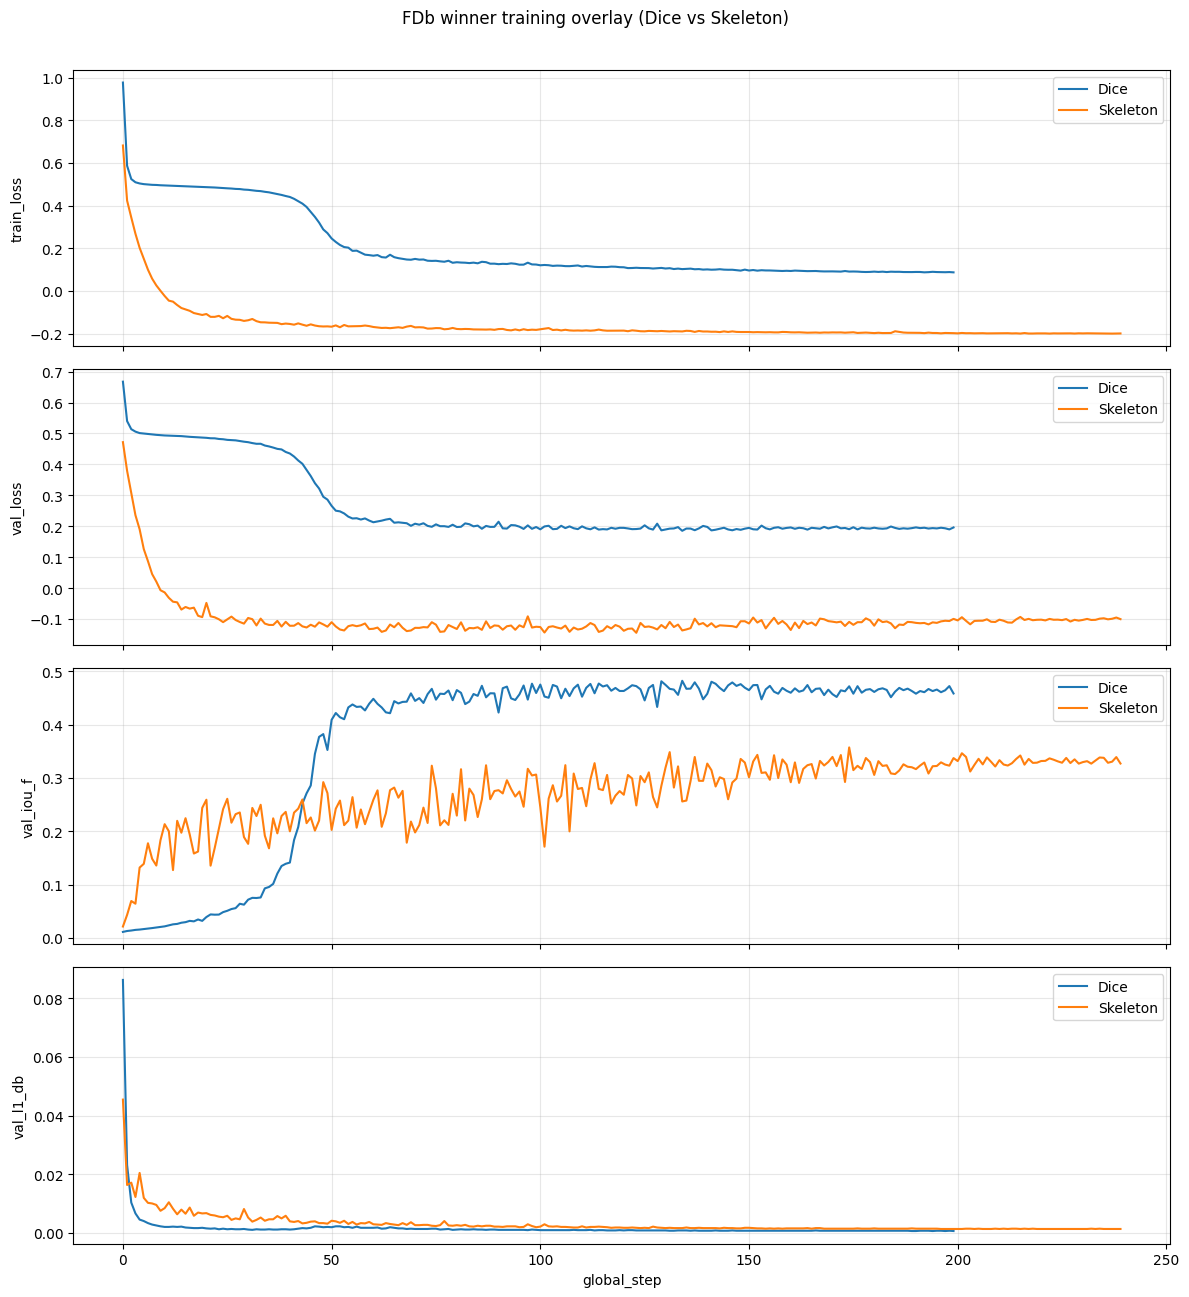

In [6]:
# Overlay shared metrics across runs
shared = [
    c
    for c in ("train_loss", "val_loss", "val_iou_f", "val_l1_db", "val_skel_recall")
    if all(c in df.columns for df in train_dfs.values() if not df.empty)
]

n = len(shared)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, metric in zip(axes, shared):
    for name, df in train_dfs.items():
        if df.empty or metric not in df.columns:
            continue
        ax.plot(df["global_step"], df[metric], label=name, linewidth=1.5)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("global_step")
fig.suptitle("FDb winner training overlay (Dice vs Skeleton)", y=1.01)
fig.tight_layout()
plt.show()

## Test metrics (`test_results_metrics.csv`)

Mean over the 7 FISBe test samples. Detection @0.5 / @0.75 is often zero; @0.3 and post-processing columns usually carry the signal.

In [7]:
DET_FIELDS = ["precision", "recall", "f1", "panoptic_quality"]
THRESHOLDS = ["0.3", "0.5", "0.75"]

DET_COLS = [f"{th} TH {field}" for th in THRESHOLDS for field in DET_FIELDS]
POST_COLS = [f"{th} TH (post){field}" for th in THRESHOLDS for field in DET_FIELDS]
CHANNEL_COLS = [
    "iou (f channel)",
    "iou (c channel)",
    "l1 (db channel)",
    "l1 (dn channel)",
]


def load_test_metrics(name: str, path: Path) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    df.insert(0, "run", name)
    stem = (
        df["file"]
        .astype(str)
        .str.replace(r"\.zarr$", "", regex=True)
        .str.replace(r"\.tiff?$", "", regex=True)
    )
    df.insert(1, "stem", stem)
    return df


test_frames = [
    load_test_metrics(name, cfg["test_csv"]) for name, cfg in RUNS.items()
]
test_metrics = pd.concat(test_frames, ignore_index=True)
print(f"{len(test_metrics)} rows from {test_metrics['run'].nunique()} run(s)")
test_metrics[["run", "stem"]].value_counts().rename("n").reset_index()

14 rows from 2 run(s)


,run,stem,n
0,Dice,JRC_SS04989-20160318_24_A2,1
1,Dice,R14A02-20180905_65_A6,1
2,Dice,R54A09-20181019_64_H1,1
3,Dice,VT011145-20171222_63_I1,1
4,Dice,VT027175-20171031_62_H3,1
5,Dice,VT027175-20171031_62_H4,1
6,Dice,VT050157-20171110_61_C1,1
7,Skeleton,JRC_SS04989-20160318_24_A2,1
8,Skeleton,R14A02-20180905_65_A6,1
9,Skeleton,R54A09-20181019_64_H1,1


In [8]:
SUMMARY_COLS = [
    c for c in CHANNEL_COLS + DET_COLS + POST_COLS if c in test_metrics.columns
]

test_means = (
    test_metrics.groupby("run", sort=False)[SUMMARY_COLS]
    .mean()
    .T
)
test_means.round(4)

run,Dice,Skeleton
0.3 TH precision,0.1429,0.0
0.3 TH recall,0.1429,0.0
0.3 TH f1,0.1429,0.0
0.3 TH panoptic_quality,0.0480,0.0
0.5 TH precision,0.0000,0.0
0.5 TH recall,0.0000,0.0
0.5 TH f1,0.0000,0.0
0.5 TH panoptic_quality,0.0000,0.0
0.75 TH precision,0.0000,0.0
0.75 TH recall,0.0000,0.0


In [9]:
HEADLINE = [
    "0.3 TH precision",
    "0.3 TH recall",
    "0.3 TH f1",
    "0.3 TH panoptic_quality",
    "0.3 TH (post)f1",
    "0.3 TH (post)panoptic_quality",
    "0.5 TH (post)f1",
    "0.75 TH (post)f1",
]
HEADLINE = [c for c in HEADLINE if c in test_metrics.columns]

headline = (
    test_metrics.groupby("run", sort=False)[HEADLINE]
    .mean()
    .round(4)
)
headline

,0.3 TH precision,0.3 TH recall,0.3 TH f1,0.3 TH panoptic_quality,0.3 TH (post)f1,0.3 TH (post)panoptic_quality,0.5 TH (post)f1,0.75 TH (post)f1
run,,,,,,,,
Dice,0.1429,0.1429,0.1429,0.048,0.1429,0.048,0.0,0.0
Skeleton,0.0000,0.0000,0.0000,0.000,0.0000,0.000,0.0,0.0


In [10]:
# Per-sample @0.3 F1 / PQ side-by-side
per_sample_cols = [
    c
    for c in (
        "0.3 TH f1",
        "0.3 TH panoptic_quality",
        "0.3 TH (post)f1",
        "0.3 TH (post)panoptic_quality",
    )
    if c in test_metrics.columns
]

per_sample = (
    test_metrics.pivot_table(index="stem", columns="run", values=per_sample_cols)
    .sort_index()
)
per_sample.round(4)

0.3 TH (post)f1           \
run                                   Dice Skeleton   
stem                                                  
JRC_SS04989-20160318_24_A2             0.0      0.0   
R14A02-20180905_65_A6                  0.0      0.0   
R54A09-20181019_64_H1                  1.0      0.0   
VT011145-20171222_63_I1                0.0      0.0   
VT027175-20171031_62_H3                0.0      0.0   
VT027175-20171031_62_H4                0.0      0.0   
VT050157-20171110_61_C1                0.0      0.0   

                           0.3 TH (post)panoptic_quality          0.3 TH f1  \
run                                                 Dice Skeleton      Dice   
stem                                                                          
JRC_SS04989-20160318_24_A2                        0.0000      0.0       0.0   
R14A02-20180905_65_A6                             0.0000      0.0       0.0   
R54A09-20181019_64_H1                             0.3359      0.0       1.0   
VT011145-20171222_63_I1                           0.0000      0.0       0.0   
VT027175-20171031_62_H3                           0.0000      0.0       0.0   
VT027175-20171031_62_H4                           0.0000      0.0       0.0   
VT050157-20171110_61_C1                           0.0000      0.0       0.0   

                                    0.3 TH panoptic_quality           
run                        Skeleton                    Dice Skeleton  
stem                                                                  
JRC_SS04989-20160318_24_A2      0.0                  0.0000      0.0  
R14A02-20180905_65_A6           0.0                  0.0000      0.0  
R54A09-20181019_64_H1           0.0                  0.3359      0.0  
VT011145-20171222_63_I1         0.0                  0.0000      0.0  
VT027175-20171031_62_H3         0.0                  0.0000      0.0  
VT027175-20171031_62_H4         0.0                  0.0000      0.0  
VT050157-20171110_61_C1         0.0                  0.0000      0.0

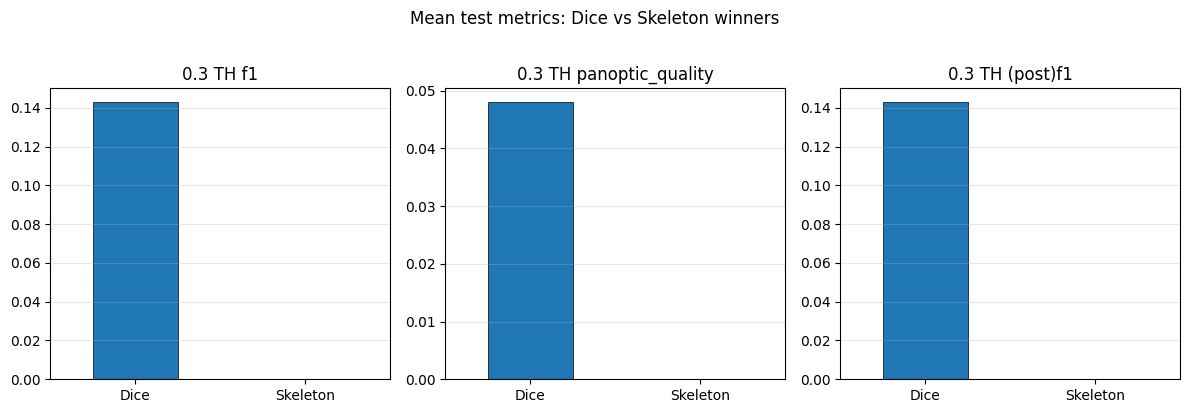

In [11]:
plot_cols = [c for c in ("0.3 TH f1", "0.3 TH panoptic_quality", "0.3 TH (post)f1") if c in headline.columns]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * max(len(plot_cols), 1), 4), sharey=False)
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    headline[col].plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Mean test metrics: Dice vs Skeleton winners", y=1.02)
fig.tight_layout()
plt.show()

## Confusion matrices (instance detection)

BiaPy reports **TP / FP / FN** per IoU threshold (true negatives are undefined for unmatched instance detection). Matrices below sum counts over the 7 test samples. Default: `@0.3` pre- and post-processing.

In [ ]:
import numpy as np

CM_THRESHOLDS = ["0.3"]  # add "0.5", "0.75" if useful
CM_VARIANTS = [("", "pre"), ("(post)", "post")]


def detection_counts(df: pd.DataFrame, th: str, post: str) -> dict:
    """Sum TP/FP/FN over samples for one threshold / pre-post variant."""
    prefix = f"{th} TH {post}"
    cols = {k: f"{prefix}{k}" for k in ("tp", "fp", "fn")}
    missing = [c for c in cols.values() if c not in df.columns]
    if missing:
        raise KeyError(f"missing columns: {missing}")
    return {k: int(df[c].sum()) for k, c in cols.items()}


def confusion_matrix_2x2(tp: int, fp: int, fn: int) -> np.ndarray:
    # [[TP, FN], [FP, TN]]; TN left as nan (not defined)
    return np.array([[tp, fn], [fp, np.nan]], dtype=float)


cm_rows = []
for name, cfg in RUNS.items():
    run_df = test_metrics[test_metrics["run"] == name]
    for th in CM_THRESHOLDS:
        for post, label in CM_VARIANTS:
            counts = detection_counts(run_df, th, post)
            cm_rows.append({"run": name, "threshold": th, "variant": label, **counts})

cm_table = pd.DataFrame(cm_rows)
display(cm_table)

n_runs = len(RUNS)
n_panels = len(CM_THRESHOLDS) * len(CM_VARIANTS)
fig, axes = plt.subplots(
    n_runs,
    n_panels,
    figsize=(3.6 * n_panels, 3.2 * n_runs),
    squeeze=False,
)

for r_i, name in enumerate(RUNS):
    run_df = test_metrics[test_metrics["run"] == name]
    for c_i, (th, (post, label)) in enumerate(
        ((th, v) for th in CM_THRESHOLDS for v in CM_VARIANTS)
    ):
        ax = axes[r_i][c_i]
        counts = detection_counts(run_df, th, post)
        mat = confusion_matrix_2x2(**counts)
        im = ax.imshow(np.nan_to_num(mat, nan=0.0), cmap="Blues", vmin=0)

        labels = np.array([["TP", "FN"], ["FP", "TN"]])
        for i in range(2):
            for j in range(2):
                val = mat[i, j]
                text = "n/a" if np.isnan(val) else str(int(val))
                ax.text(
                    j,
                    i,
                    f"{labels[i, j]}\n{text}",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=11,
                )
        ax.set_xticks([0, 1], ["Pred+", "Pred−"])
        ax.set_yticks([0, 1], ["GT+", "GT−"])
        ax.set_title(f"{name} @ IoU {th} ({label})")

fig.suptitle("Detection confusion (summed over test samples)", y=1.02)
fig.tight_layout()
plt.show()
plt.close(fig)

## Optional: full per-run training tables

Uncomment to inspect every epoch.

In [12]:
# train_dfs["Dice"]
# train_dfs["Skeleton"]
for name, df in train_dfs.items():
    display(name, df.tail(3))

'Dice'

,partition,epoch,global_step,train_loss,val_loss,train_iou_f,train_l1_db,val_iou_f,val_l1_db,lr,early_stopped
197,0,198,197,0.0888,0.1937,0.7102,0.0007,0.4646,0.0007,0.00001,False
198,0,199,198,0.0895,0.1901,0.7080,0.0007,0.4725,0.0008,0.00001,False
199,0,200,199,0.0882,0.1964,0.7118,0.0007,0.4586,0.0007,0.00001,False


'Skeleton'

,partition,epoch,global_step,train_loss,val_loss,train_iou_f,train_l1_db,val_iou_f,val_l1_db,lr,early_stopped
237,0,238,237,-0.1989,-0.0986,0.3089,0.0013,0.3307,0.0014,0.00001,False
238,0,239,238,-0.1985,-0.0946,0.3111,0.0013,0.3393,0.0014,0.00001,False
239,0,240,239,-0.1982,-0.0998,0.3146,0.0013,0.3272,0.0014,0.00001,False
